<a href="https://colab.research.google.com/github/ayesha-tubassum/fdlkdjg/blob/main/RANDOM_FOREST(titanic_datset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1) Import Libraries**

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# **2) Data Loading**

In [5]:
df = pd.read_csv("/content/tested.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# **3) Data Cleaning**

In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [7]:
df["Age"].fillna(df["Age"].median(), inplace=True)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

df.drop("Cabin", axis=1, inplace=True)

/tmp/ipykernel_1807/851712005.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_1807/851712005.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

# **4) Data Visualization (EDA)**

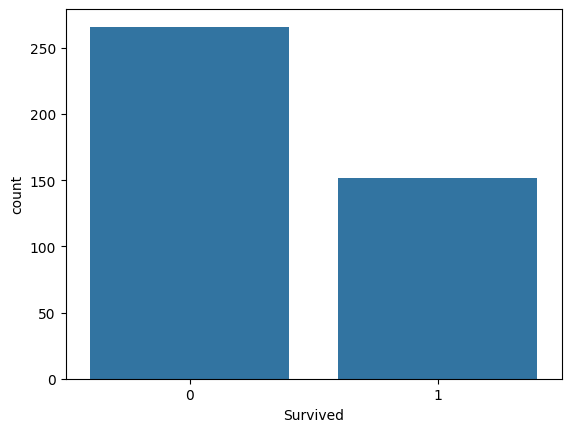

In [8]:
sns.countplot(x="Survived", data=df)
plt.show()

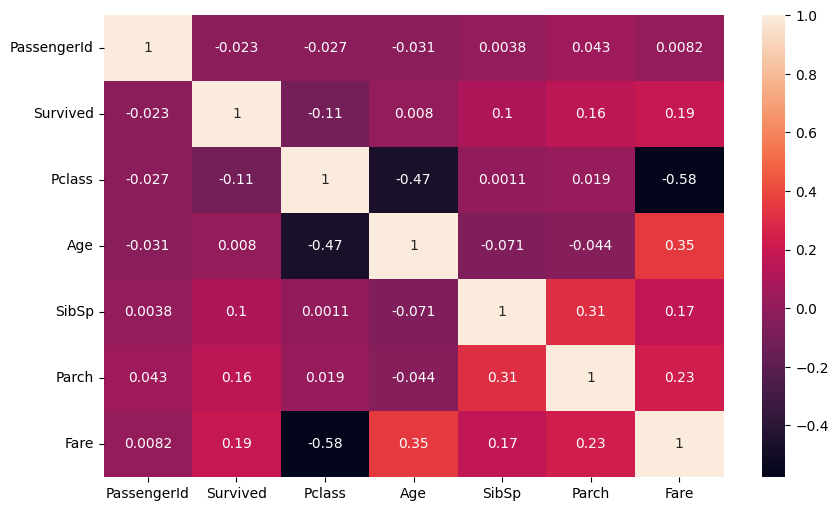

In [9]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

# **5) Feature Engineering**

In [10]:
df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1
})

In [11]:
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

# **6) Drop Unnecessary Columns**

In [12]:
df.drop(["Name", "Ticket", "PassengerId"], axis=1, inplace=True)

# **7) Define X and y**

In [13]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

# **8) Train-Test Split**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **9) Model Selection**

In [15]:
model = RandomForestClassifier()

# **10) Model Training**

In [16]:
model.fit(X_train, y_train)

RandomForestClassifier()

# **11) Model Prediction**

In [17]:
y_pred = model.predict(X_test)

## **12) Model Evaluation**

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



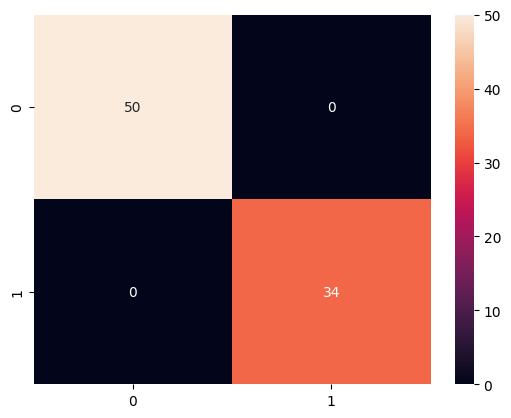

In [20]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

plt.show()

# **13) Model Tuning**

In [21]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 3, 'n_estimators': 50}


# **14) Cross Validation**

In [22]:
scores = cross_val_score(
    RandomForestClassifier(),
    X,
    y,
    cv=5
)

print(scores)

print("Average Score:", scores.mean())

[1. 1. 1. 1. 1.]
Average Score: 1.0


# **15) Pipeline Building**

In [23]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("model", RandomForestClassifier())
])

pipeline.fit(X_train, y_train)

pred = pipeline.predict(X_test)

print(accuracy_score(y_test, pred))

1.0


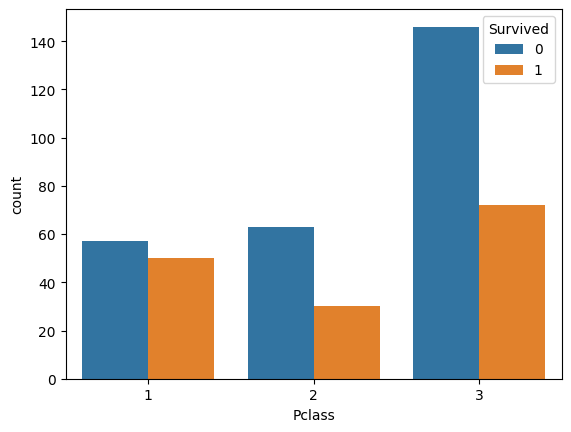

In [24]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.show()

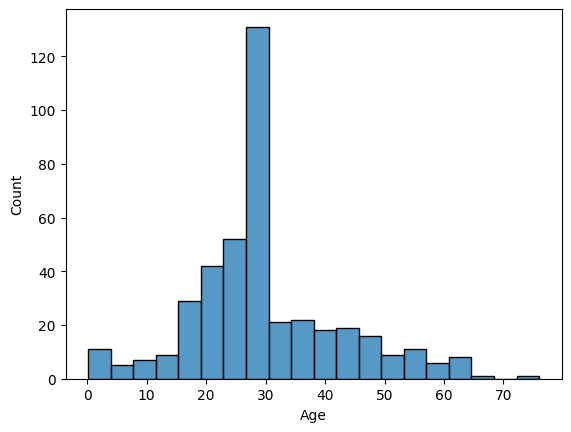

In [25]:
sns.histplot(df["Age"], bins=20)
plt.show()